# Step 7b — CNN Text Classifier
**Project:** SDG Mapping for PhD Thesis

**Purpose:** Train a TextCNN model for SDG classification

**Architecture:** Kim (2014) TextCNN — multiple filter sizes capture different n-gram patterns

**Inputs:** `data/clean/X_train_tfidf.csv` · `data/clean/y_train.csv`

**Outputs:** `data/results/mahe_top5_cnn.csv` · `data/results/step7b_cnn_results.csv`

> Note: Running on CPU — training takes 20-30 minutes

> Reference: Kim, Y. (2014). Convolutional Neural Networks for Sentence Classification. EMNLP.

In [1]:
# Cell 1: Install
!pip install torch torchtext pandas numpy scikit-learn matplotlib tqdm


   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ----------------------------- ---------- 0.8/1.1 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 2.4 MB/s eta 0:00:00

   ---------------------------------------- 2/2 [torchtext]



In [2]:
# Cell 2: Imports
import json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

CLEAN_DIR   = Path('data/clean')
RESULTS_DIR = Path('data/results')
PLOT_DIR    = Path('data/plots')
MODELS_DIR  = Path('data/models')

with open('data/step2_meta.json') as f:
    meta = json.load(f)
SDG_NAMES = {int(k): v for k, v in meta['sdg_names'].items()}

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')
print('Imports complete')


Device: cpu
Imports complete


In [3]:
# Cell 3: Load data
X_train_raw = pd.read_csv(CLEAN_DIR / 'X_train_tfidf.csv')['text'].fillna('').tolist()
X_test_raw  = pd.read_csv(CLEAN_DIR / 'X_test_tfidf.csv')['text'].fillna('').tolist()
y_train_raw = pd.read_csv(CLEAN_DIR / 'y_train.csv')['sdg'].tolist()
y_test_raw  = pd.read_csv(CLEAN_DIR / 'y_test.csv')['sdg'].tolist()
mahe_raw    = pd.read_csv(CLEAN_DIR / 'mahe_tfidf.csv')['text'].fillna('').tolist()
mahe_df     = pd.read_csv(CLEAN_DIR / 'mahe_corpus.csv')

# Encode labels to 0-indexed integers
le = LabelEncoder()
le.fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_test  = le.transform(y_test_raw)
n_classes = len(le.classes_)

print(f'X_train : {len(X_train_raw):,}')
print(f'X_test  : {len(X_test_raw):,}')
print(f'MAHE    : {len(mahe_raw):,}')
print(f'Classes : {n_classes} SDGs -> {list(le.classes_)}')


X_train : 27,204
X_test  : 6,801
MAHE    : 854
Classes : 16 SDGs -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


In [4]:
# Cell 4: Build vocabulary
MAX_VOCAB = 20000
MAX_LEN   = 128    # truncate/pad all texts to 128 tokens
PAD_IDX   = 0
UNK_IDX   = 1

# Count token frequencies in training set
counter = Counter()
for text in X_train_raw:
    counter.update(text.split())

# Build vocab: most frequent MAX_VOCAB-2 words + PAD + UNK
vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
for word, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

print(f'Vocabulary size : {len(vocab):,}')
print(f'Max sequence len: {MAX_LEN}')
print(f'PAD index       : {PAD_IDX}')
print(f'UNK index       : {UNK_IDX}')


Vocabulary size : 20,000
Max sequence len: 128
PAD index       : 0
UNK index       : 1


In [5]:
# Cell 5: Text -> token index sequence
def text_to_indices(text, vocab, max_len, pad_idx, unk_idx):
    tokens = text.split()[:max_len]
    ids    = [vocab.get(t, unk_idx) for t in tokens]
    # Pad or truncate to max_len
    ids    = ids + [pad_idx] * (max_len - len(ids))
    return ids

# Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.data   = [
            torch.tensor(text_to_indices(t, vocab, max_len, PAD_IDX, UNK_IDX), dtype=torch.long)
            for t in texts
        ]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

class InferenceDataset(Dataset):
    def __init__(self, texts, vocab, max_len):
        self.data = [
            torch.tensor(text_to_indices(t, vocab, max_len, PAD_IDX, UNK_IDX), dtype=torch.long)
            for t in texts
        ]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

train_dataset = TextDataset(X_train_raw, y_train, vocab, MAX_LEN)
test_dataset  = TextDataset(X_test_raw,  y_test,  vocab, MAX_LEN)
mahe_dataset  = InferenceDataset(mahe_raw, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)
mahe_loader  = DataLoader(mahe_dataset,  batch_size=64, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'MAHE batches  : {len(mahe_loader)}')


Train batches : 426
Test batches  : 107
MAHE batches  : 14


In [6]:
# Cell 6: TextCNN architecture (Kim 2014)
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_classes,
                 filter_sizes, n_filters, dropout):
        super(TextCNN, self).__init__()
        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Parallel convolutional filters of different sizes
        # Each filter_size captures n-gram patterns of that length
        self.convs = nn.ModuleList([
            nn.Conv2d(
                in_channels=1,
                out_channels=n_filters,
                kernel_size=(fs, embed_dim)
            )
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        # Final fully connected layer
        self.fc = nn.Linear(len(filter_sizes) * n_filters, n_classes)

    def forward(self, x):
        # x shape: (batch, seq_len)
        embedded = self.embedding(x)           # (batch, seq_len, embed_dim)
        embedded = embedded.unsqueeze(1)        # (batch, 1, seq_len, embed_dim)

        # Apply each conv filter + ReLU + max-pool
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))      # (batch, n_filters, seq_len-fs+1, 1)
            c = c.squeeze(3)                    # (batch, n_filters, seq_len-fs+1)
            c = torch.max(c, dim=2).values      # (batch, n_filters) -- max pooling
            pooled.append(c)

        cat = torch.cat(pooled, dim=1)          # (batch, len(filter_sizes)*n_filters)
        cat = self.dropout(cat)
        return self.fc(cat)                     # (batch, n_classes)


# Hyperparameters
EMBED_DIM    = 128
FILTER_SIZES = [2, 3, 4]   # bigrams, trigrams, 4-grams
N_FILTERS    = 100
DROPOUT      = 0.5
EPOCHS       = 10
LR           = 0.001

model_cnn = TextCNN(
    vocab_size   = len(vocab),
    embed_dim    = EMBED_DIM,
    n_classes    = n_classes,
    filter_sizes = FILTER_SIZES,
    n_filters    = N_FILTERS,
    dropout      = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print('TextCNN Architecture:')
print(model_cnn)
print(f'\nTotal trainable parameters: {total_params:,}')
print(f'Filter sizes: {FILTER_SIZES} (bigrams, trigrams, 4-grams)')
print(f'Filters per size: {N_FILTERS}')
print(f'Embedding dim: {EMBED_DIM}')


TextCNN Architecture:
TextCNN(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv2d(1, 100, kernel_size=(2, 128), stride=(1, 1))
    (1): Conv2d(1, 100, kernel_size=(3, 128), stride=(1, 1))
    (2): Conv2d(1, 100, kernel_size=(4, 128), stride=(1, 1))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=16, bias=True)
)

Total trainable parameters: 2,680,316
Filter sizes: [2, 3, 4] (bigrams, trigrams, 4-grams)
Filters per size: 100
Embedding dim: 128


In [7]:
# Cell 7: Training loop
optimizer = optim.Adam(model_cnn.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accs   = []
val_f1s      = []

print(f'Training TextCNN for {EPOCHS} epochs on CPU...')
print(f'Estimated time: 20-30 minutes')
print()

for epoch in range(EPOCHS):
    model_cnn.train()
    epoch_loss = 0
    correct    = 0
    total      = 0
    start      = time.time()

    for texts, labels in train_loader:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        output = model_cnn(texts)
        loss   = criterion(output, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        preds      = output.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    # Validation
    model_cnn.eval()
    all_preds = []
    all_true  = []
    with torch.no_grad():
        for texts, labels in test_loader:
            texts = texts.to(DEVICE)
            out   = model_cnn(texts)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(labels.numpy())

    all_preds_orig = le.inverse_transform(all_preds)
    all_true_orig  = le.inverse_transform(all_true)
    val_f1 = f1_score(all_true_orig, all_preds_orig, average='macro', zero_division=0)

    avg_loss = epoch_loss / len(train_loader)
    acc      = correct / total
    elapsed  = time.time() - start

    train_losses.append(avg_loss)
    train_accs.append(acc)
    val_f1s.append(val_f1)

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {acc:.4f} | Val Macro F1: {val_f1:.4f} | Time: {elapsed:.0f}s')

# Save model
torch.save(model_cnn.state_dict(), MODELS_DIR / 'textcnn.pt')
print(f'\nModel saved: data/models/textcnn.pt')


Training TextCNN for 10 epochs on CPU...
Estimated time: 20-30 minutes

Epoch  1/10 | Loss: 1.8364 | Train Acc: 0.4672 | Val Macro F1: 0.6882 | Time: 22s
Epoch  2/10 | Loss: 1.1846 | Train Acc: 0.6635 | Val Macro F1: 0.7274 | Time: 22s
Epoch  3/10 | Loss: 1.0061 | Train Acc: 0.7090 | Val Macro F1: 0.7436 | Time: 24s
Epoch  4/10 | Loss: 0.8802 | Train Acc: 0.7436 | Val Macro F1: 0.7612 | Time: 24s
Epoch  5/10 | Loss: 0.7866 | Train Acc: 0.7691 | Val Macro F1: 0.7670 | Time: 24s
Epoch  6/10 | Loss: 0.6824 | Train Acc: 0.8006 | Val Macro F1: 0.7802 | Time: 25s
Epoch  7/10 | Loss: 0.5978 | Train Acc: 0.8230 | Val Macro F1: 0.7820 | Time: 23s
Epoch  8/10 | Loss: 0.5223 | Train Acc: 0.8468 | Val Macro F1: 0.7914 | Time: 24s
Epoch  9/10 | Loss: 0.4546 | Train Acc: 0.8633 | Val Macro F1: 0.7927 | Time: 24s
Epoch 10/10 | Loss: 0.3873 | Train Acc: 0.8853 | Val Macro F1: 0.7930 | Time: 29s

Model saved: data/models/textcnn.pt


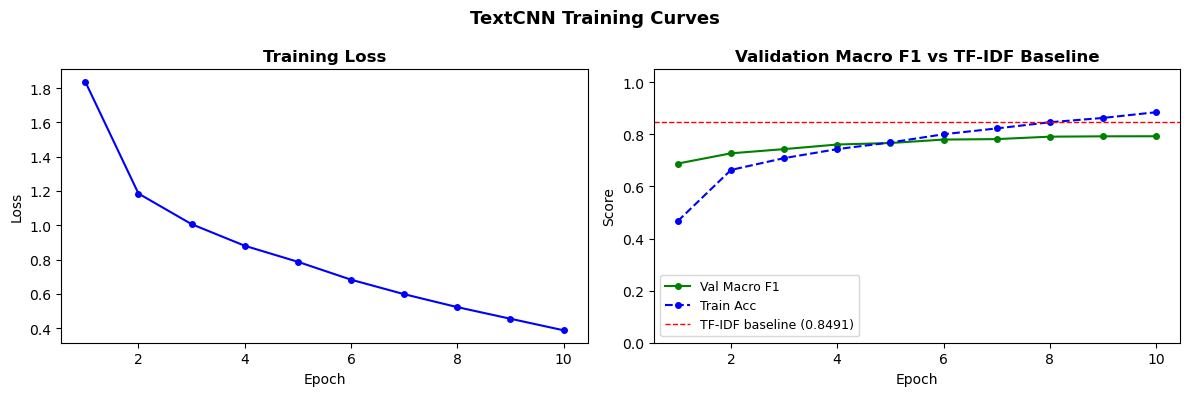

Training curves saved


In [8]:
# Cell 8: Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', markersize=4)
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(range(1, EPOCHS+1), val_f1s, 'g-o', markersize=4, label='Val Macro F1')
axes[1].plot(range(1, EPOCHS+1), train_accs, 'b--o', markersize=4, label='Train Acc')
axes[1].axhline(0.8491, color='red', linestyle='--', linewidth=1, label='TF-IDF baseline (0.8491)')
axes[1].set_title('Validation Macro F1 vs TF-IDF Baseline', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

plt.suptitle('TextCNN Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '14_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved')


In [9]:
# Cell 9: Final CNN evaluation
best_epoch_f1 = max(val_f1s)
best_epoch    = val_f1s.index(best_epoch_f1) + 1

# Final test set evaluation
model_cnn.eval()
final_preds = []
final_true  = []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(DEVICE)
        out   = model_cnn(texts)
        preds = out.argmax(dim=1).cpu().numpy()
        final_preds.extend(preds)
        final_true.extend(labels.numpy())

final_preds_orig = le.inverse_transform(final_preds)
final_true_orig  = le.inverse_transform(final_true)

cnn_f1  = f1_score(final_true_orig, final_preds_orig, average='macro', zero_division=0)
cnn_p   = precision_score(final_true_orig, final_preds_orig, average='macro', zero_division=0)
cnn_r   = recall_score(final_true_orig, final_preds_orig, average='macro', zero_division=0)
cnn_acc = accuracy_score(final_true_orig, final_preds_orig)

print('=== TextCNN Final Evaluation ===')
print(f'  Macro F1   : {cnn_f1:.4f}')
print(f'  Precision  : {cnn_p:.4f}')
print(f'  Recall     : {cnn_r:.4f}')
print(f'  Accuracy   : {cnn_acc:.4f}')
print(f'  Best epoch : {best_epoch}/{EPOCHS}')

cnn_result = pd.DataFrame([{
    'Representation': 'CNN', 'Classifier': 'TextCNN',
    'Macro F1': round(cnn_f1, 4), 'Macro Precision': round(cnn_p, 4),
    'Macro Recall': round(cnn_r, 4), 'Accuracy': round(cnn_acc, 4),
}])
cnn_result.to_csv(RESULTS_DIR / 'step7b_cnn_results.csv', index=False)
print('Saved: data/results/step7b_cnn_results.csv')


=== TextCNN Final Evaluation ===
  Macro F1   : 0.7930
  Precision  : 0.8023
  Recall     : 0.7892
  Accuracy   : 0.8234
  Best epoch : 10/10
Saved: data/results/step7b_cnn_results.csv


In [10]:
# Cell 10: Top-5 SDG predictions for MAHE using CNN
print(f'Generating top-5 predictions for {len(mahe_raw):,} MAHE articles...')

model_cnn.eval()
all_probs = []
with torch.no_grad():
    for texts in mahe_loader:
        texts = texts.to(DEVICE)
        out   = model_cnn(texts)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        all_probs.extend(probs)

all_probs = np.array(all_probs)

def softmax_np(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

cnn_mahe_results = []
for i in range(len(mahe_raw)):
    proba      = all_probs[i]
    sorted_idx = np.argsort(proba)[::-1]
    top5_enc   = [sorted_idx[j] for j in range(5)]
    top5_sdgs  = [int(le.classes_[j]) for j in top5_enc]
    top5_scores = [round(float(proba[j]), 4) for j in top5_enc]
    top5_names  = [SDG_NAMES.get(s, f'SDG {s}') for s in top5_sdgs]
    top5_soft   = softmax_np(np.array(top5_scores)).round(4).tolist()
    title = str(mahe_df.iloc[i]['title']) if 'title' in mahe_df.columns else str(mahe_df.iloc[i]['text'])[:80]
    cnn_mahe_results.append({
        'Title':         title,
        'Rank1_SDG':     f'SDG {top5_sdgs[0]}', 'Rank1_Name': top5_names[0], 'Rank1_Score': top5_scores[0], 'Rank1_Softmax': top5_soft[0],
        'Rank2_SDG':     f'SDG {top5_sdgs[1]}', 'Rank2_Name': top5_names[1], 'Rank2_Score': top5_scores[1],
        'Rank3_SDG':     f'SDG {top5_sdgs[2]}', 'Rank3_Name': top5_names[2], 'Rank3_Score': top5_scores[2],
        'Rank4_SDG':     f'SDG {top5_sdgs[3]}', 'Rank4_Name': top5_names[3], 'Rank4_Score': top5_scores[3],
        'Rank5_SDG':     f'SDG {top5_sdgs[4]}', 'Rank5_Name': top5_names[4], 'Rank5_Score': top5_scores[4],
        'Top5_SDGs':     ', '.join([f'SDG {s}' for s in top5_sdgs]),
        'All_Probs':     ', '.join([f'SDG {int(le.classes_[j])}:{proba[j]:.4f}' for j in np.argsort(proba)[::-1]]),
    })

df_cnn_mahe = pd.DataFrame(cnn_mahe_results)
df_cnn_mahe.to_csv(RESULTS_DIR / 'mahe_top5_cnn.csv', index=False, encoding='utf-8-sig')
print(f'Saved: data/results/mahe_top5_cnn.csv')
print()
print('Sample CNN predictions:')
print(df_cnn_mahe[['Title','Rank1_SDG','Rank1_Name','Rank1_Score','Top5_SDGs']].head(5).to_string())


Generating top-5 predictions for 854 MAHE articles...
Saved: data/results/mahe_top5_cnn.csv

Sample CNN predictions:
                                                                                                                 Title Rank1_SDG                               Rank1_Name  Rank1_Score                             Top5_SDGs
0                 Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib     SDG 9  Industry, Innovation and Infrastructure       0.3466   SDG 9, SDG 6, SDG 7, SDG 11, SDG 12
1                           ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education    SDG 16   Peace, Justice and Strong Institutions       0.5389   SDG 16, SDG 4, SDG 9, SDG 8, SDG 10
2                 Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon in Natural Resource Management    SDG 13                           Climate Action       0.1969  SDG 13, SDG 7, SDG 11, SDG 15, SDG 9

In [11]:
# Cell 11: Step 7b summary
tfidf_best = 0.8491
improvement = cnn_f1 - tfidf_best
diff_str = f'+{improvement:.4f}' if improvement >= 0 else f'{improvement:.4f}'

print('=' * 62)
print('  STEP 7b - CNN SUMMARY')
print('=' * 62)
print()
print('  Architecture : TextCNN (Kim 2014)')
print(f'  Filter sizes : {FILTER_SIZES} (bigrams, trigrams, 4-grams)')
print(f'  Filters/size : {N_FILTERS}')
print(f'  Embed dim    : {EMBED_DIM}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Vocab size   : {len(vocab):,}')
print()
print(f'  CNN Macro F1 : {cnn_f1:.4f}')
print(f'  TF-IDF best  : {tfidf_best:.4f}')
print(f'  Difference   : {diff_str}')
print()
if cnn_f1 > tfidf_best:
    print('  CNN outperforms TF-IDF baseline')
elif cnn_f1 > tfidf_best - 0.02:
    print('  CNN performance comparable to TF-IDF')
else:
    print('  TF-IDF still leads — CNN needs more data or fine-tuning')
print()
print('  Output files:')
print('    mahe_top5_cnn.csv        - CNN top-5 predictions')
print('    step7b_cnn_results.csv   - CNN evaluation metrics')
print('    14_cnn_training_curves.png')
print()
print('Step 7b complete -> next: step8_clustering_evaluation.ipynb')
print('=' * 62)


  STEP 7b - CNN SUMMARY

  Architecture : TextCNN (Kim 2014)
  Filter sizes : [2, 3, 4] (bigrams, trigrams, 4-grams)
  Filters/size : 100
  Embed dim    : 128
  Epochs       : 10
  Vocab size   : 20,000

  CNN Macro F1 : 0.7930
  TF-IDF best  : 0.8491
  Difference   : -0.0561

  TF-IDF still leads — CNN needs more data or fine-tuning

  Output files:
    mahe_top5_cnn.csv        - CNN top-5 predictions
    step7b_cnn_results.csv   - CNN evaluation metrics
    14_cnn_training_curves.png

Step 7b complete -> next: step8_clustering_evaluation.ipynb
